In [1]:
!pip install mne openneuro-py
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 114.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
import openneuro as on
on.download(dataset='ds002778', target_dir='/content/eeglab_data')


👋 Hello! This is openneuro-py 2026.4.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds002778 …
📥 Retrieving up to 328 files (5 concurrent downloads). 

✅ Finished downloading ds002778.
 
🧠 Please enjoy your brains.
 


In [8]:
raw_bdf=mne.io.read_raw_bdf('/content/eeglab_data/sub-hc1/ses-hc/eeg/sub-hc1_ses-hc_task-rest_eeg.bdf',
                            preload=True)
print(raw_bdf.info)

Extracting BDF parameters from /content/eeglab_data/sub-hc1/ses-hc/eeg/sub-hc1_ses-hc_task-rest_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 98303  =      0.000 ...   191.998 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 40 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 104.0 Hz
 meas_date: 2011-01-19 11:22:56 UTC
 nchan: 41
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>


In [11]:
EEG_CHANNELS_BDF=['Fp1', 'F3', 'Fz', 'F4', 'Pz']
L_FREQ_BDF=0.5
H_FREQ_BDF=40.0
F_MAX=40.0

raw_bdf_filtered=raw_bdf.copy().filter(l_freq=L_FREQ_BDF, h_freq=H_FREQ_BDF)
raw_bdf_filtered.pick(EEG_CHANNELS_BDF)
print("filterling complete")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (6.604 s)

filterling complete


Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_10736/1852431893.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig=psd.plot()


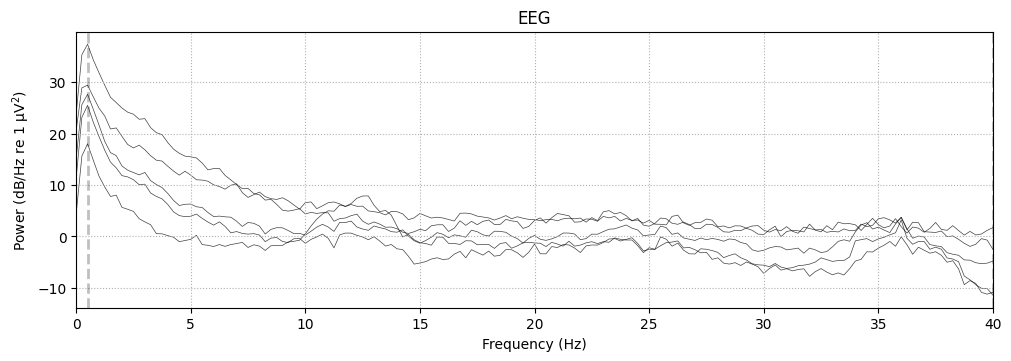

In [12]:
psd=raw_bdf_filtered.compute_psd(fmax=F_MAX)
fig=psd.plot()
plt.show()

In [18]:
raw_pd=mne.io.read_raw_bdf('/content/eeglab_data/sub-pd3/ses-off/eeg/sub-pd3_ses-off_task-rest_eeg.bdf',
                           preload=True)

raw_pd_filtered=raw_pd.copy().filter(l_freq=L_FREQ_BDF, h_freq=H_FREQ_BDF)
raw_pd_filtered.pick(EEG_CHANNELS_BDF)
print("filterling complete")

Extracting BDF parameters from /content/eeglab_data/sub-pd3/ses-off/eeg/sub-pd3_ses-off_task-rest_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 102399  =      0.000 ...   199.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (6.604 s)

filterling complete


In [17]:
import os
for item in os.listdir('/content/eeglab_data'):
  if 'pd' in item:
    print(item)

sub-pd12
sub-pd11
sub-pd9
sub-pd5
sub-pd26
sub-pd19
sub-pd17
sub-pd14
sub-pd28
sub-pd23
sub-pd6
sub-pd13
sub-pd3
sub-pd22
sub-pd16


Effective window size : 4.000 (s)
Effective window size : 4.000 (s)


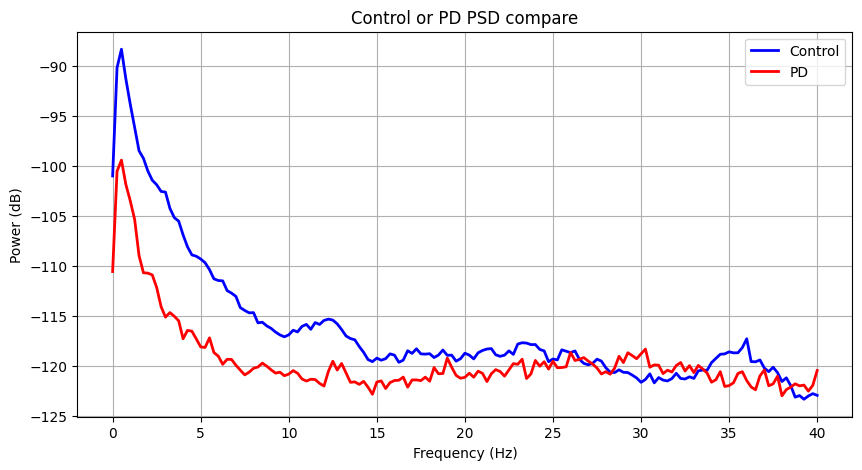

In [19]:
psd_hc=raw_bdf_filtered.compute_psd(fmax=F_MAX)
psd_pd=raw_pd_filtered.compute_psd(fmax=F_MAX)

freqs=psd_hc.freqs
power_hc=psd_hc.get_data().mean(axis=0)
power_pd=psd_pd.get_data().mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(freqs, 10 * np.log10(power_hc), label='Control', color='blue', linewidth=2)
plt.plot(freqs, 10 * np.log10(power_pd), label='PD', color='red', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title('Control or PD PSD compare')
plt.legend()
plt.grid(True)
plt.show()